In [1]:
#import libraries 
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
#import data
df = pd.read_csv("jiji_housing_raw.csv")

**Data Inspection**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               2000 non-null   str    
 1   property_size       1995 non-null   float64
 2   house_type          1984 non-null   str    
 3   bedrooms            1999 non-null   float64
 4   bathrooms           1999 non-null   float64
 5   furnishing          1999 non-null   str    
 6   region              2000 non-null   str    
 7   region_name         2000 non-null   str    
 8   region_parent_name  1995 non-null   str    
 9   is_boost            2000 non-null   str    
 10  price               2000 non-null   str    
dtypes: float64(3), str(8)
memory usage: 402.0 KB


In [4]:
df.shape

(2000, 11)

In [5]:
df.isnull().sum()

title                  0
property_size          5
house_type            16
bedrooms               1
bathrooms              1
furnishing             1
region                 0
region_name            0
region_parent_name     5
is_boost               0
price                  0
dtype: int64

In [6]:
df.head()

,title,property_size,house_type,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,2bdrm Maisonette in Lekki Phase 1 for sale,185.0,Maisonette,2.0,2.0,unfurnished,"Lekki, Lekki Phase 1",Lekki Phase 1,Lekki,diamond,"₦ 350,000,000"
1,4bdrm Duplex in Thomas Estate for sale,300.0,Duplex,4.0,4.0,semi-furnished,"Ajah, Thomas Estate",Thomas Estate,Ajah,enterprise,"₦ 300,000,000"
2,"5bdrm Duplex in Lekki Palm City, Ado / Ajah fo...",300.0,Duplex,5.0,5.0,semi-furnished,"Ajah, Ado / Ajah",Ado / Ajah,Ajah,enterprise,"₦ 300,000,000"
3,"4bdrm Duplex in Golden Park Estate, Sangotedo ...",300.0,Duplex,4.0,4.0,semi-furnished,"Ajah, Sangotedo",Sangotedo,Ajah,enterprise,"₦ 275,000,000"
4,Mini Flat in Mende for sale,120.0,NaN,1.0,1.0,unfurnished,"Maryland, Mende",Mende,Maryland,vip_gold,"₦ 75,000,000"


**Data Cleaning**

In [7]:
#dropping null values
df = df.dropna()

In [8]:
#turning float columns to int
df["property_size"] = (
    df["property_size"]
    .astype(float)
    .astype(int)
)
df["bedrooms"] = (
    df["bedrooms"]
    .astype(float)
    .astype(int)
)
df["bathrooms"] = (
    df["bathrooms"]
    .astype(float)
    .astype(int)
)

In [9]:
#standardizing text in 'furnishing' and 'is_boost'
df["furnishing"] = (
    df["furnishing"]
    .str.strip()
    .str.title()
)
df["is_boost"] = (
    df["is_boost"]
    .str.strip()
    .str.title()
)

In [10]:
#changing price to float
df["price"] = (
    df["price"]
    .astype(str)
    .replace('[₦,]', "", regex=True)
    .astype(float)
)


In [11]:
#checking outliers in price
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

detect_outlier = (
    (df["price"] < lower_bound) | (df["price"] > upper_bound)
)
print(detect_outlier.sum())

186


In [12]:
#dropping outliers
df = df.drop(df[detect_outlier].index)

In [13]:
df = df.rename(columns={
    "property_size": "property_size(sqm)"
})

In [14]:
df.head()

,title,property_size(sqm),house_type,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,2bdrm Maisonette in Lekki Phase 1 for sale,185,Maisonette,2,2,Unfurnished,"Lekki, Lekki Phase 1",Lekki Phase 1,Lekki,Diamond,350000000.0
1,4bdrm Duplex in Thomas Estate for sale,300,Duplex,4,4,Semi-Furnished,"Ajah, Thomas Estate",Thomas Estate,Ajah,Enterprise,300000000.0
2,"5bdrm Duplex in Lekki Palm City, Ado / Ajah fo...",300,Duplex,5,5,Semi-Furnished,"Ajah, Ado / Ajah",Ado / Ajah,Ajah,Enterprise,300000000.0
3,"4bdrm Duplex in Golden Park Estate, Sangotedo ...",300,Duplex,4,4,Semi-Furnished,"Ajah, Sangotedo",Sangotedo,Ajah,Enterprise,275000000.0
5,5bdrm Duplex in Idu for sale,700,Duplex,5,6,Unfurnished,"Jiwa, Idu",Idu,Jiwa,False,350000000.0


In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 1791 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1791 non-null   str    
 1   property_size(sqm)  1791 non-null   int64  
 2   house_type          1791 non-null   str    
 3   bedrooms            1791 non-null   int64  
 4   bathrooms           1791 non-null   int64  
 5   furnishing          1791 non-null   str    
 6   region              1791 non-null   str    
 7   region_name         1791 non-null   str    
 8   region_parent_name  1791 non-null   str    
 9   is_boost            1791 non-null   str    
 10  price               1791 non-null   float64
dtypes: float64(1), int64(3), str(7)
memory usage: 348.6 KB


In [16]:
df.reset_index()

,index,title,property_size(sqm),house_type,bedrooms,bathrooms,furnishing,region,region_name,region_parent_name,is_boost,price
0,0,2bdrm Maisonette in Lekki Phase 1 for sale,185,Maisonette,2,2,Unfurnished,"Lekki, Lekki Phase 1",Lekki Phase 1,Lekki,Diamond,350000000.0
1,1,4bdrm Duplex in Thomas Estate for sale,300,Duplex,4,4,Semi-Furnished,"Ajah, Thomas Estate",Thomas Estate,Ajah,Enterprise,300000000.0
2,2,"5bdrm Duplex in Lekki Palm City, Ado / Ajah fo...",300,Duplex,5,5,Semi-Furnished,"Ajah, Ado / Ajah",Ado / Ajah,Ajah,Enterprise,300000000.0
3,3,"4bdrm Duplex in Golden Park Estate, Sangotedo ...",300,Duplex,4,4,Semi-Furnished,"Ajah, Sangotedo",Sangotedo,Ajah,Enterprise,275000000.0
4,5,5bdrm Duplex in Idu for sale,700,Duplex,5,6,Unfurnished,"Jiwa, Idu",Idu,Jiwa,False,350000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1786,1995,"Furnished 4bdrm Duplex in Country Mews Court, ...",1296,Duplex,4,4,Furnished,"Lagos State, Ibeju",Ibeju,Lagos State,Enterprise,110000000.0
1787,1996,"4bdrm Duplex in Secured Estate, Wempco Road fo...",270,Duplex,4,4,Semi-Furnished,"Ogba, Wempco Road",Wempco Road,Ogba,Enterprise,340000000.0
1788,1997,"5bdrm Duplex in Royal Pine Estate, Lekki Phase...",350,Duplex,5,5,Semi-Furnished,"Lekki, Lekki Phase 2",Lekki Phase 2,Lekki,Enterprise,480000000.0
1789,1998,"5bdrm Duplex in Royal Pine Estate, Lekki Phase...",340,Duplex,5,5,Semi-Furnished,"Lekki, Lekki Phase 2",Lekki Phase 2,Lekki,Enterprise,480000000.0


In [17]:
df = df.to_csv("jiji_housing_cleaned.csv", index=False)

**EDA - Data Analysis**

In [18]:
df = pd.read_csv("jiji_housing_cleaned.csv")

In [19]:
#price analysis 
avg_price = df["price"].mean()

print("Average house price:", round(avg_price, 2))

Average house price: 296521630.37


In [20]:
df.groupby("region_parent_name")["price"].mean().sort_values(ascending=False).map('{:,.0f}'.format)

region_parent_name
Ikoyi              592,500,000
Garki 1            575,000,000
Victoria Island    550,000,000
Ilupeju            538,750,000
Ogudu              521,666,667
Ikeja              511,642,857
Magodo             434,000,000
Apo District       427,500,000
Maryland           388,947,368
Lekki              364,634,578
Surulere           318,131,579
Abuja (FCT)        308,299,539
Ojodu              289,285,714
Lagos State        284,112,299
Amuwo-Odofin       280,000,000
Agege              277,833,333
Gbagada            277,272,727
Ogba               272,727,273
Enugu State        270,000,000
Gwagwa             265,375,000
Egbeda             264,000,000
Alimosho           247,500,000
Port-Harcourt      241,818,182
Ajah               239,794,393
Katampe            233,409,091
Rivers State       212,696,429
Isolo              200,000,000
Jiwa               191,000,000
Yaba               185,000,000
Delta State        180,000,000
Gwarinpa           168,656,250
Imo State          1

In [21]:
#distribution of property size
print(df["property_size(sqm)"].describe())

count    1791.000000
mean      514.775544
std       358.632053
min        10.000000
25%       350.000000
50%       465.000000
75%       600.000000
max      5000.000000
Name: property_size(sqm), dtype: float64


In [22]:
df["bedrooms"].unique()

array([ 2,  4,  5,  3, 15, 14,  6, 10,  1,  7, 20, 18, 11,  8,  9, 12, 16])

In [23]:
df.groupby("bedrooms")["price"].agg(["count", "mean", "median"]).map('{:,.0f}'.format)

,count,mean,median
bedrooms,,,
1,21,"63,209,524","40,000,000"
2,208,"174,930,288","142,500,000"
3,311,"187,771,190","140,000,000"
4,598,"266,680,602","220,000,000"
5,568,"439,667,254","400,000,000"
6,41,"340,658,537","230,000,000"
7,11,"482,500,000","450,000,000"
8,7,"225,000,000","165,000,000"
9,3,"273,333,333","300,000,000"


In [24]:
# plt.scatter(df["bedrooms"], df["price"])
# plt.xlabel("Number of Bedrooms")
# plt.ylabel("Price")
# plt.title("Bedrooms vs Property Price")
# plt.show()

# plt.scatter(df["bathrooms"], df["price"])
# plt.xlabel("Number of Bathrooms")
# plt.ylabel("Price")
# plt.title("Bathrooms vs Property Price")
# plt.show()

In [25]:
df["bathrooms"].unique()

array([ 2,  4,  5,  6,  3, 12,  7,  1, 11, 16, 17, 10, 20,  9,  8, 18, 14,
       13])

In [26]:
df.groupby("bathrooms")["price"].agg(["count", "mean", "median"]).map('{:,.0f}'.format)

,count,mean,median
bathrooms,,,
1,41,"329,326,829","250,000,000"
2,174,"173,140,805","150,000,000"
3,281,"188,975,231","150,000,000"
4,562,"248,351,957","200,000,000"
5,591,"406,148,054","370,000,000"
6,86,"420,017,442","395,000,000"
7,20,"463,150,000","425,000,000"
8,13,"325,192,308","315,000,000"
9,2,"252,500,000","252,500,000"


In [27]:
df[["bedrooms", "bathrooms", "price"]].corr()

,bedrooms,bathrooms,price
bedrooms,1.000000,0.875726,0.279136
bathrooms,0.875726,1.000000,0.252041
price,0.279136,0.252041,1.000000


In [28]:
#regional trends
df["region_parent_name"].value_counts().head(10)

region_parent_name
Lekki           509
Lagos State     374
Abuja (FCT)     217
Ajah            107
Ikeja            70
Gwarinpa         64
Ipaja            31
Ogun State       30
Rivers State     28
Magodo           25
Name: count, dtype: int64

In [29]:
#regions dominating premium property sales
df.groupby("region_parent_name")["price"].sum().sort_values(ascending=False).map('{:,.0f}'.format).head(10)

region_parent_name
Lekki           185,599,000,000
Lagos State     106,258,000,000
Abuja (FCT)      66,901,000,000
Ikeja            35,815,000,000
Ajah             25,658,000,000
Magodo           10,850,000,000
Gwarinpa         10,794,000,000
Maryland          7,390,000,000
Surulere          6,044,500,000
Rivers State      5,955,500,000
Name: price, dtype: str

In [30]:
#Are furnished apartments more expensive on average?
df.groupby("furnishing")["price"].mean().sort_values(ascending=False).map('{:,.0f}'.format)

furnishing
Semi-Furnished    316,715,385
Unfurnished       298,033,288
Furnished         241,394,194
Name: price, dtype: str

In [31]:
#Do boosted/enterprise listings have higher prices?
df.groupby("is_boost")["price"].mean().sort_values(ascending=False).map('{:,.0f}'.format)

is_boost
Basic         600,000,000
Enterprise    319,767,145
Vip           305,000,000
Premium       300,000,000
Vip_Gold      229,500,000
False         208,961,905
Diamond       203,496,053
Name: price, dtype: str

In [32]:
#analysis of house type
df["house_type"].value_counts().sort_values(ascending=False)

house_type
Duplex               1203
Apartment             235
Block of Flats        148
Bungalow              120
House                  43
Maisonette             21
Penthouse               8
Townhouse/Terrace       4
Mansion                 4
Room & Parlour          3
Condo                   1
Villa                   1
Name: count, dtype: int64

In [33]:
df.groupby("house_type")["price"].mean().sort_values(ascending=False).map('{:,.0f}'.format)

house_type
Villa                650,000,000
Mansion              423,750,000
Penthouse            372,500,000
Duplex               349,786,318
Maisonette           294,666,667
House                290,534,884
Apartment            228,188,936
Townhouse/Terrace    163,750,000
Block of Flats       161,972,973
Condo                113,000,000
Bungalow              65,165,833
Room & Parlour        29,000,000
Name: price, dtype: str

In [34]:
df.groupby("house_type")["price"].sum().sort_values(ascending=False).map('{:,.0f}'.format)

house_type
Duplex               420,792,940,000
Apartment             53,624,400,000
Block of Flats        23,972,000,000
House                 12,493,000,000
Bungalow               7,819,899,999
Maisonette             6,188,000,000
Penthouse              2,980,000,000
Mansion                1,695,000,000
Townhouse/Terrace        655,000,000
Villa                    650,000,000
Condo                    113,000,000
Room & Parlour            87,000,000
Name: price, dtype: str

**Data Visualization**

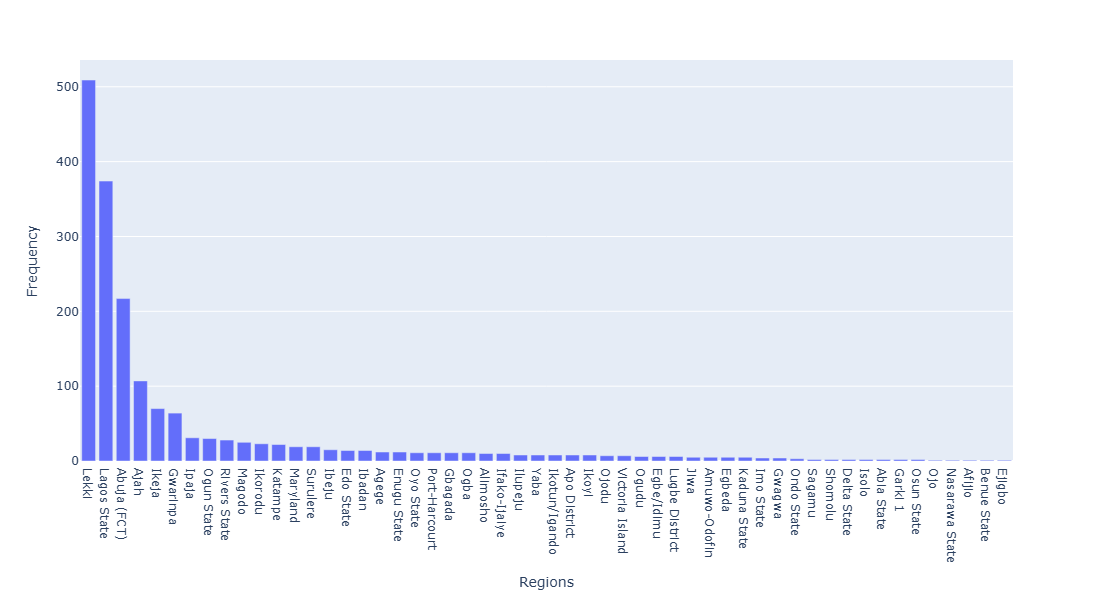

In [37]:
#bar chart for region count
region_count = df["region_parent_name"].value_counts()
fig1 = px.bar(
    x=region_count.index,
    y=region_count.values,
)
fig1.update_layout(
    xaxis_title='Regions',
    yaxis_title='Frequency',
    height=600
)
fig1.show()

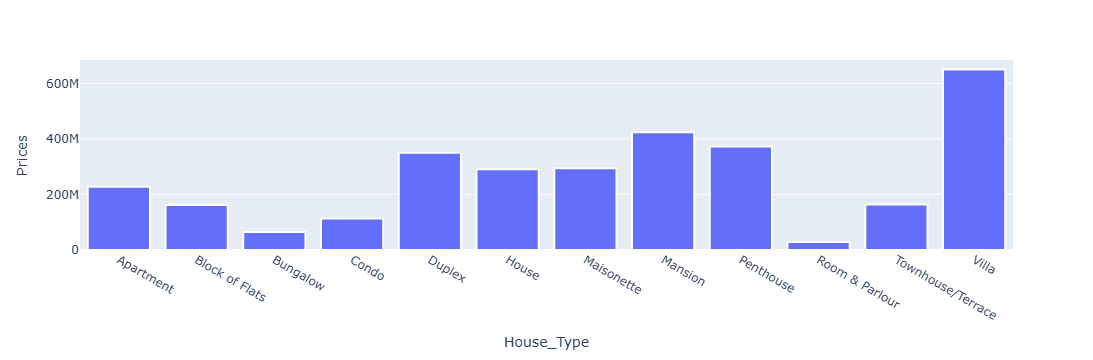

In [41]:
#histogram for house type by price
property_prices = df.groupby("house_type")['price'].mean()
fig2 = px.histogram(
    x=property_prices.index,
    y=property_prices.values,
)
fig2.update_layout(
    xaxis_title='House_Type',
    yaxis_title='Prices'
)
fig2.update_traces(
marker_line_color="white",
marker_line_width=2
)
fig2.show()

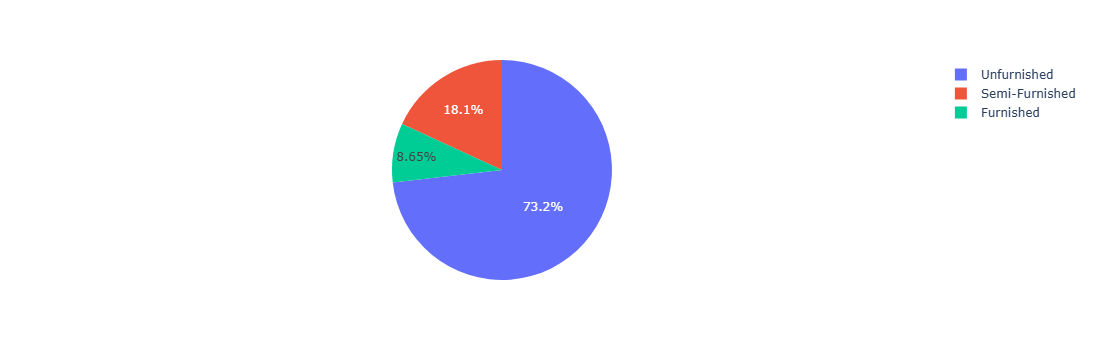

In [43]:
#pie chart 
furnish_count = df["furnishing"].value_counts()
fig3 = px.pie(
    values=furnish_count.values,
    names=furnish_count.index,
)
fig3.show()

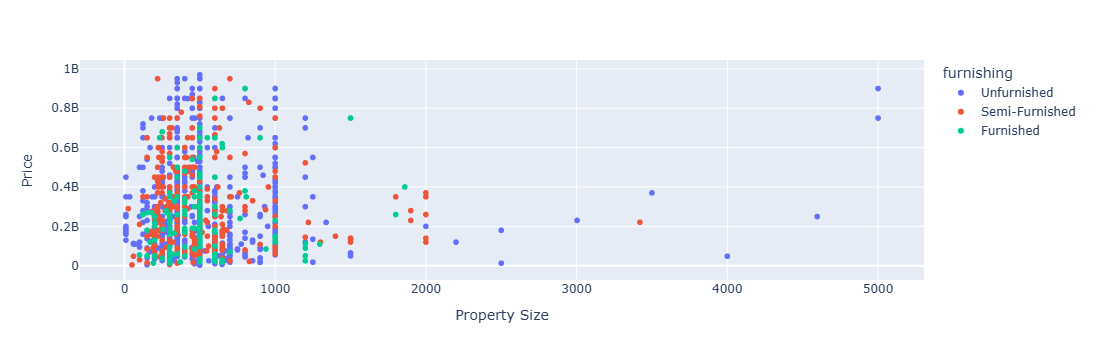

In [45]:
#scatter plot 
fig4 = px.scatter(
    df,
    x="property_size(sqm)",
    y="price",
    color="furnishing",
    labels={
        "property_size(sqm)": "Property Size",
        "price": "Price"
    }
)
fig4.show()

**Summary Report and Reccommendation**

**Key Findings**
* The highest-priced markets were concentrated in premium locations such as **Ikoyi, Garki 1, Victoria Island, Ilupeju, and Ogudu**, while lower averages appeared in **Ogun, Edo, Kaduna, Osun, Ibadan, and Ikorodu**.
* Furnished homes were not consistently more expensive: **semi-furnished listings** averaged **₦316.7M**, **unfurnished ₦298.0M**, while **furnished homes** averaged **₦241.4M**.
* Bedrooms and bathrooms have a **positive but relatively weak relationship** with price (correlations of **0.279** and **0.252** respectively), although **prices generally rise for larger 4–7 bedroom homes**.
* Enterprise listings were not typically the most expensive: they averaged ₦319.8M, compared with **₦600M for Basic listings** and **₦305M for VIP listings.**
* **Villas, mansions, penthouses, and duplexes** attracted the highest average prices, with **villas averaging about ₦650M** and **mansions ₦423.8M**.
* **Lagos** dominated the dataset and premium market, particularly **Lekki**, while **Abuja (FCT)** also recorded **high average prices** and substantial total listing value.
* Overall, **Lagos and Abuja** showed **stronger premium-market activity**, while many other regions had considerably lower average listing prices.

**Business-Focused Insight Summary**

Premium property types, such as **villas, mansions, penthouses and duplexes,** offer the **strongest pricing power**, making them important segments for sellers targeting higher-value transactions. **Lagos has the greatest revenue potential**, driven by its concentration of listings and high-value property markets; Abuja also represents a significant premium market.

Lower-priced regions outside Lagos and Abuja, including several northern and southwestern states, underperform in total revenue potential, largely because of lower average listing prices and/or smaller market activity.

Notably, the analysis file does not contain a **usable timestamp-based activity** analysis, so no specific period can be identified as having the highest listing activity.

**Recommendations**
* Sellers in weaker regions could improve performance through localized pricing, targeted digital promotion, better property photography, and partnerships with local agents.
* To increase visibility and pricing power, sellers should emphasize high-demand features, accurate property details, strong visuals, appropriate furnishing, and strategic listing promotion, rather than relying on Enterprise/boost status alone.
